# Patch & Model

Patch counts: {'up': 21, 'dn': 21}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]

===== kept indices in full loop =====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23]

===== up exact-M21 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ] | E=1.0947644253e-47 | |vF|=7.747470e-16 | w=[0. 1. 0.]
id= 1 | k=[-1.178097 -1.133625] | k_can=[1.963495 4.307773] | E=1.52

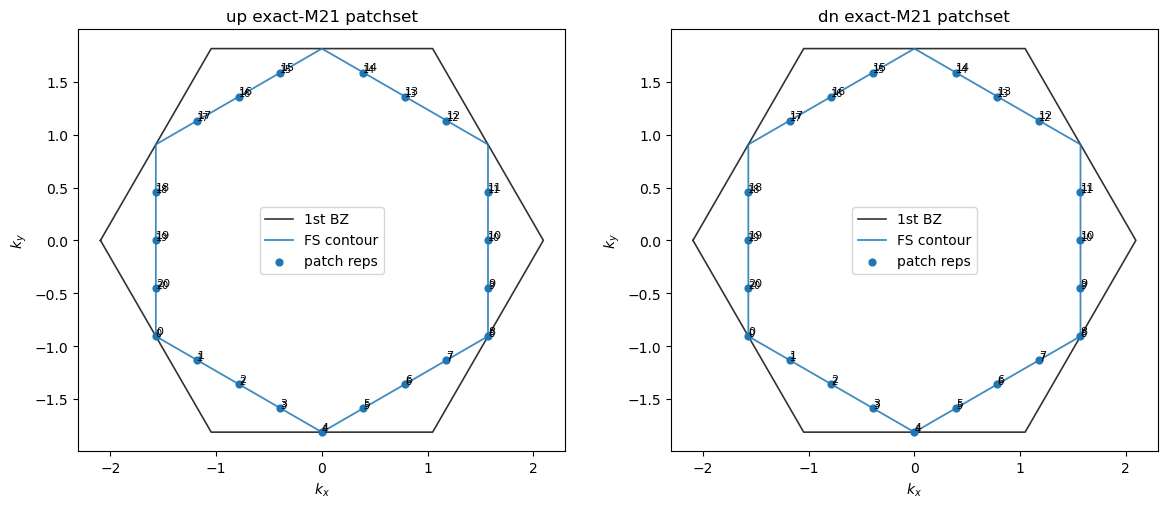

In [4]:
# ============================================================
# Required definitions BEFORE the manual exact-M patch cell
# ============================================================

# Example model params:
MODEL_PARAMS = {"t": 1.0, "phi": np.pi/4}
# If you already defined MODEL_PARAMS elsewhere, keep your own value.

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# Spinful KagomeNagaosa has 6 orbitals total:
#   up sector = first 3
#   dn sector = last 3
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)

# IMPORTANT:
# choose the band index within EACH 3x3 spin block.
# If your previous notebook already had the correct value, use that.
# For many kagome runs the local band index is often 1, but change it if needed.
LOCAL_BAND_INDEX = 1
import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(dict(t=1.0, phi=0.0), spin=True, B=None)

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 4            # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True # True: remove replicated M anchors modulo G
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
}

NPATCH = patchsets["up"].Npatch
PATCHSETS = patchsets

# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}"
    )

if REMOVE_DUPLICATE_M_MODG:
    keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, POINTS_PER_EDGE)
    print("\n===== kept indices in full loop =====")
    print(keep_idx.tolist())

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"k_can={np.round(_canonicalize_k_mod_G(model, p.k_cart), 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )

# ------------------------------------------------------------
# neighbor distance sanity check (patch reps only)
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances (patch reps only) =====")
    print(np.round(d, 8))

# ------------------------------------------------------------
# optional overlap sanity check for gauge smoothness
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    U = np.array([p.eigvec for p in patchsets[spin].patches], dtype=complex)
    ovs = []
    for i in range(len(U)):
        j = (i + 1) % len(U)
        ovs.append(np.vdot(U[i], U[j]))
    ovs = np.asarray(ovs, dtype=complex)

    print(f"\n===== {spin} neighbor overlaps after gauge fixing =====")
    print("abs  =", np.round(np.abs(ovs), 8))
    print("arg  =", np.round(np.angle(ovs), 8))

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(
        patchsets[spin],
        ax=ax,
        show_contour=True,   # contour remains the original full loop
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

# Flow

In [10]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from importlib import reload

import noninteracting
import interaction
import frg_kernel
import frg_flow
import channels

reload(noninteracting)
reload(interaction)
reload(frg_kernel)
reload(frg_flow)
reload(channels)

from interaction import BareExtendedHubbard
from frg_flow import FRGFlowSolverSZ0, BareSZ0VertexFromInteraction
from channels import SZ0ChannelBuilder

# ------------------------------------------------------------
# choose interaction case
# ------------------------------------------------------------
CASE = "U_only"   # "V_only" or "U_only"

if CASE == "V_only":
    U_TEST, V_TEST = 0.0, 8.0
elif CASE == "U_only":
    U_TEST, V_TEST = 8.0, 0.0
else:
    raise ValueError("CASE must be 'V_only' or 'U_only'")

# ------------------------------------------------------------
# flow params
# ------------------------------------------------------------
T_START = 1
T_STOP  = .5
NFREQ   = 30
NSTEPS  = 100

# choose which Q to inspect
Q_CHOICE = np.array([0.0, 0.0])  # Q=0
M6 = exact_M6_points_1bz(model)
# Q_CHOICE = np.array(M6[0], dtype=float)   # M1

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("Q_CHOICE =", np.round(Q_CHOICE, 8))
print("NPATCH =", PATCHSETS["up"].Npatch)


# ------------------------------------------------------------
# build bare interaction from the SAME model you used for patchsets
# ------------------------------------------------------------
bare_int = BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)

# minimal S_z=0 bare vertex adapter
bare_sz0 = BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,
    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,
    max_relative_update=0.20,
    min_substep_fraction=1.0/256.0,
    channel_divergence_threshold=1e8,
)

print("solver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm =", solver.state.channel_norm())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CASE = U_only  | U = 8.0  V = 0.0
T_START, T_STOP, NFREQ, NSTEPS = 1 0.5 30 100
Q_CHOICE = [0. 0.]
NPATCH = 21
solver built.
temperature path length = 100
initial channel norm = 8.0


In [8]:
# ------------------------------------------------------------
# choose representative indices along the temperature path
# index 0 = initial bare
# ------------------------------------------------------------
temps = solver.temperature_path
Ntemp = len(temps)

rep_ids = [0, Ntemp//4, Ntemp//2, 3*Ntemp//4, Ntemp-1]
rep_ids = sorted(set(rep_ids))

print("representative temperature indices:", rep_ids)
print("representative temperatures:", [float(temps[i]) for i in rep_ids])

snapshots = {}

# initial snapshot
snapshots[0] = make_snapshot_from_solver(solver, label=f"step0_T={solver.state.T:.6f}")

# manual stepping so we can store intermediate states
for i in range(Ntemp - 1):
    T_old = float(temps[i])
    T_new = float(temps[i+1])
    dT = T_new - T_old

    rec = solver.step(T_old, dT)
    rec.instability, rec.instability_reason = solver.check_instability(rec)
    solver.history.append(rec)

    if (i + 1) in rep_ids:
        snapshots[i + 1] = make_snapshot_from_solver(
            solver, label=f"step{i+1}_T={solver.state.T:.6f}"
        )

    if rec.instability:
        print("Flow stopped early at step", i+1)
        print("Reason:", rec.instability_reason)
        break

print("final stored snapshot ids:", sorted(snapshots.keys()))
print("final current T =", solver.state.T)
print("final current norm =", solver.state.channel_norm())

representative temperature indices: [0, 25, 50, 75, 99]
representative temperatures: [1.0, 0.8737373737373737, 0.7474747474747474, 0.6212121212121211, 0.5]
Flow stopped early at step 12
Reason: Adaptive step control requested too many substeps; stopping flow early. Current state remains at T=0.94444444, attempted T_new=0.93939394, rhs_norm=1.363e+07, rel_update=5.923e+01, proposed_n_sub=297.
final stored snapshot ids: [0]
final current T = 0.9444444444444444
final current norm = 1161.8510015770212


# Kernel Structure

plotting snapshot: step0_T=1.000000


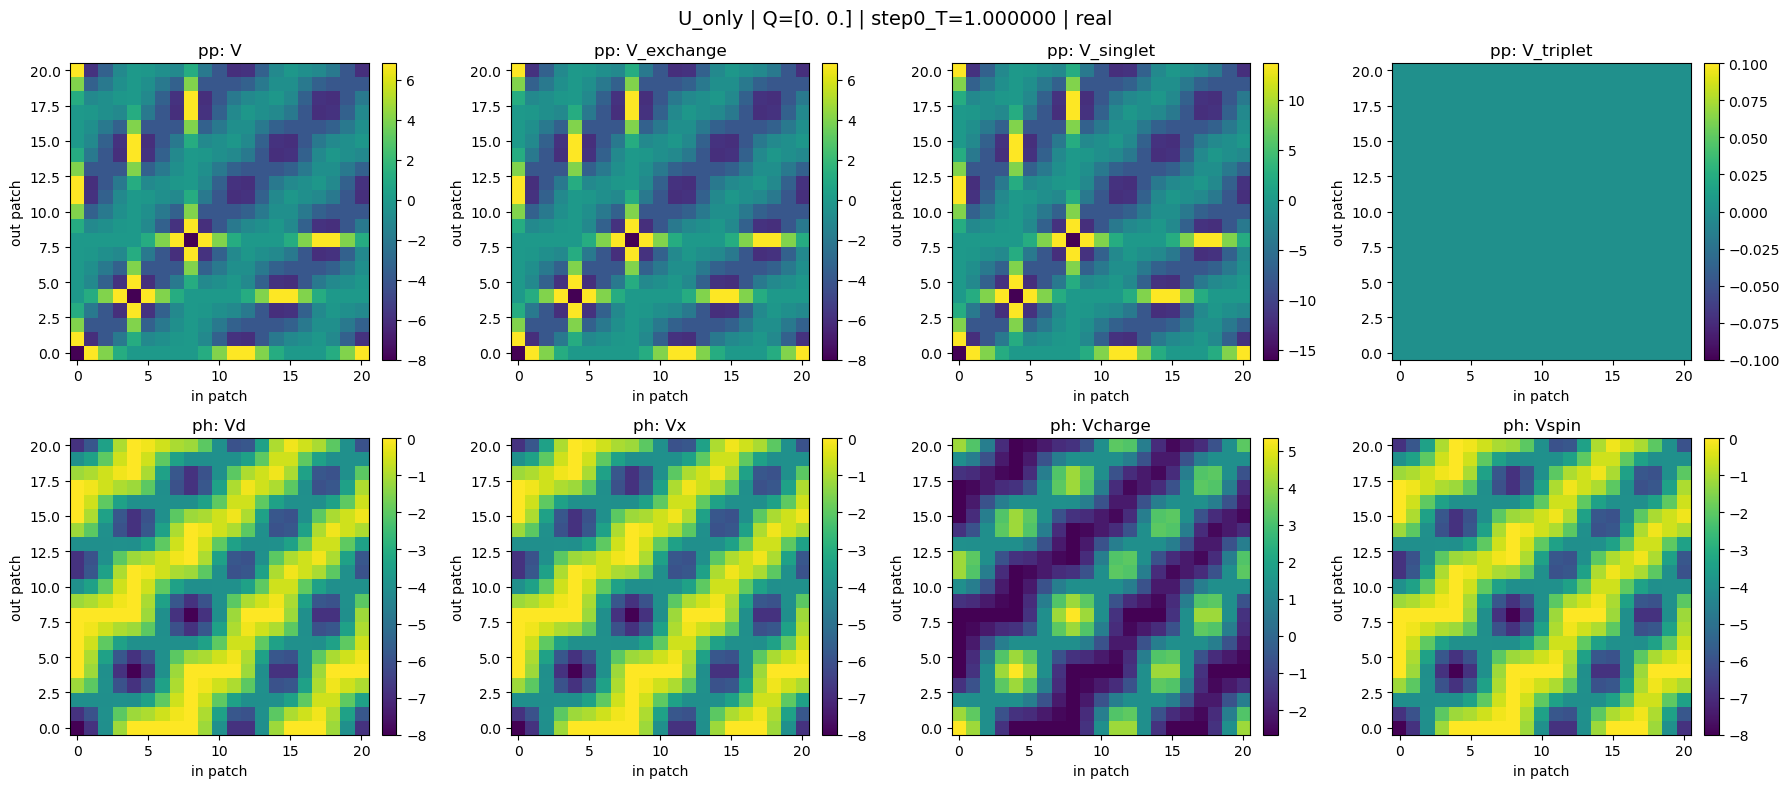

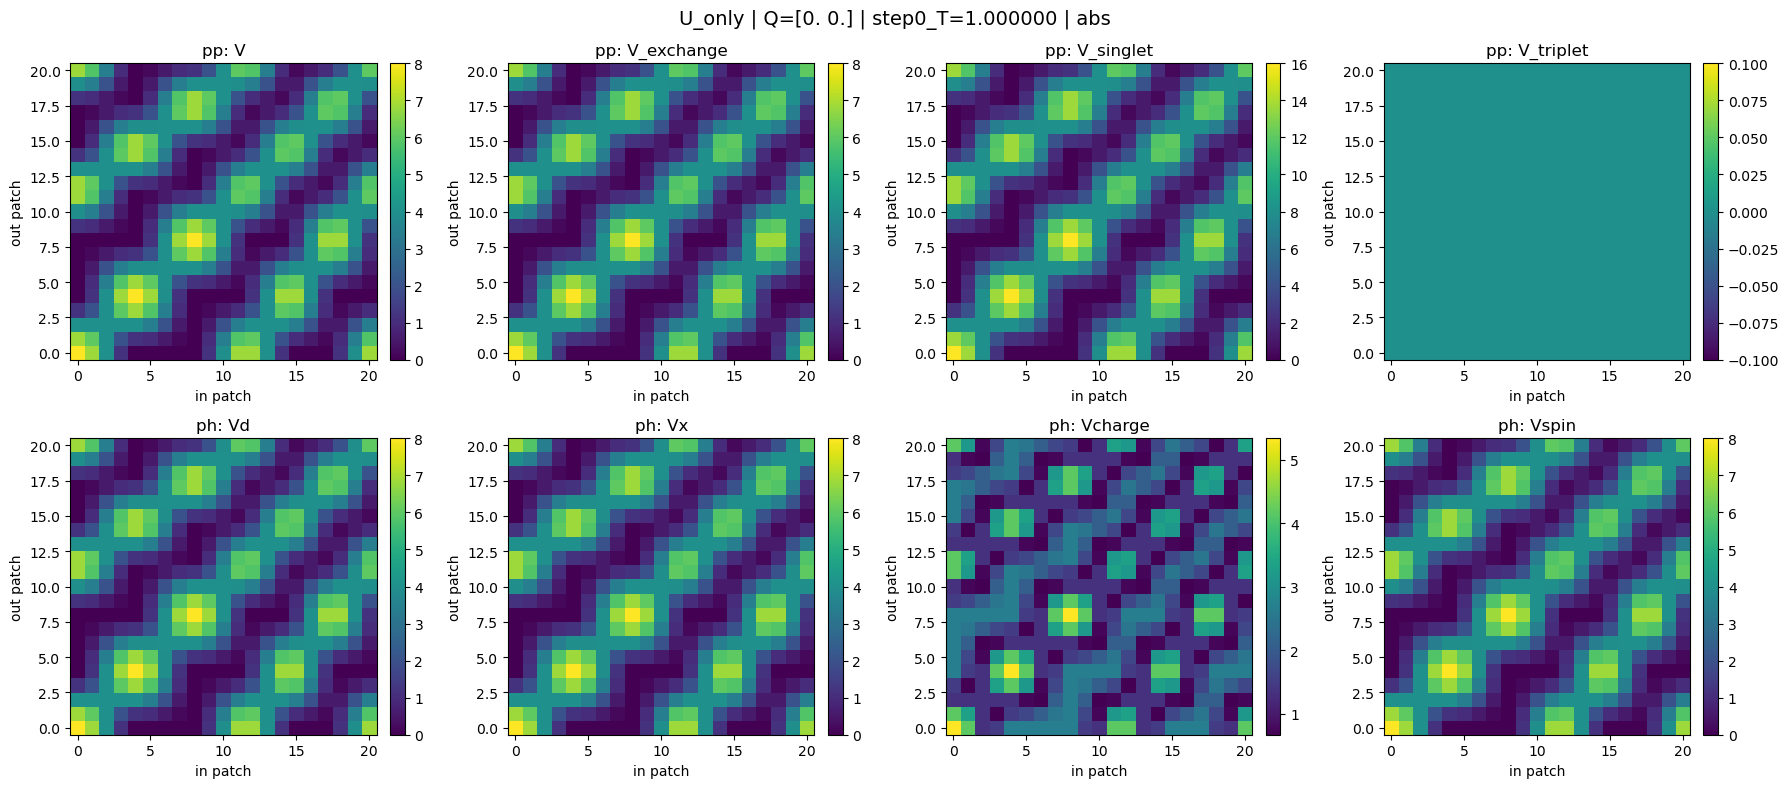

In [11]:
# ------------------------------------------------------------
# choose snapshot to plot
# ------------------------------------------------------------
sid = 0   # try 0 first for bare
snap = snapshots[sid]
bundle = kernel_bundle_at_Q(snap, solver, Q_CHOICE)

print("plotting snapshot:", snap.label)
plot_bundle_2d(bundle, title_prefix=f"{CASE} | Q={np.round(Q_CHOICE,6)} | {snap.label}", use_abs=False)
plot_bundle_2d(bundle, title_prefix=f"{CASE} | Q={np.round(Q_CHOICE,6)} | {snap.label}", use_abs=True)

snapshot: step0_T=5.000000


,kernel,max_abs_entry,lead_eval_abs,lead_eval_real,lead_eval_imag
2,pp_singlet,16.0,112.0,-112.0,1.427092e-30
6,ph_charge,8.0,56.0,56.0,2.227950e-32
5,ph_Vx,8.0,56.0,-56.0,-2.227950e-32
4,ph_Vd,8.0,56.0,-56.0,-2.227950e-32
7,ph_spin,8.0,56.0,-56.0,-2.227950e-32
0,pp_V,8.0,56.0,-56.0,7.135460e-31
1,pp_V_exchange,8.0,56.0,-56.0,7.135460e-31
3,pp_triplet,0.0,0.0,0.0,0.000000e+00


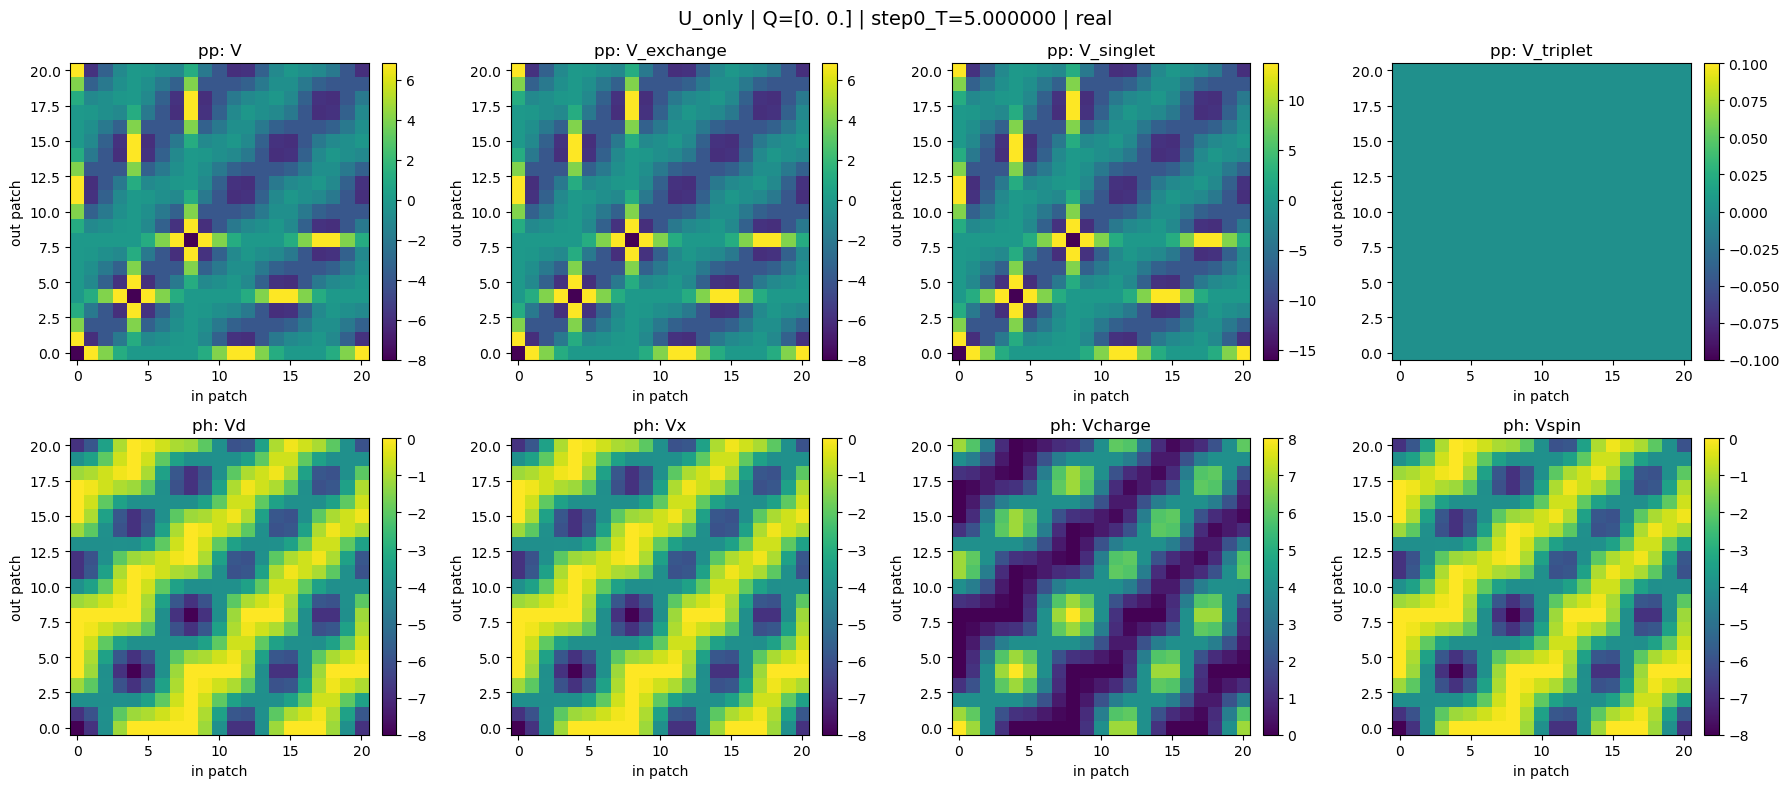

In [54]:
for sid in sorted(snapshots.keys()):
    snap = snapshots[sid]
    bundle = kernel_bundle_at_Q(snap, solver, Q_CHOICE)

    print("=" * 100)
    print("snapshot:", snap.label)
    display(summarize_bundle(bundle))

    plot_bundle_2d(
        bundle,
        title_prefix=f"{CASE} | Q={np.round(Q_CHOICE,6)} | {snap.label}",
        use_abs=False,
    )

# One Loop Diagram

Qs to check: [array([0., 0.])]
[early step 0]  T = 1.0000000000
     pp tensor max |.| = 1.589368e+02
    phd tensor max |.| = 1.589368e+02
    phc tensor max |.| = 3.392937e+01
  total tensor max |.| = 1.075501e+02


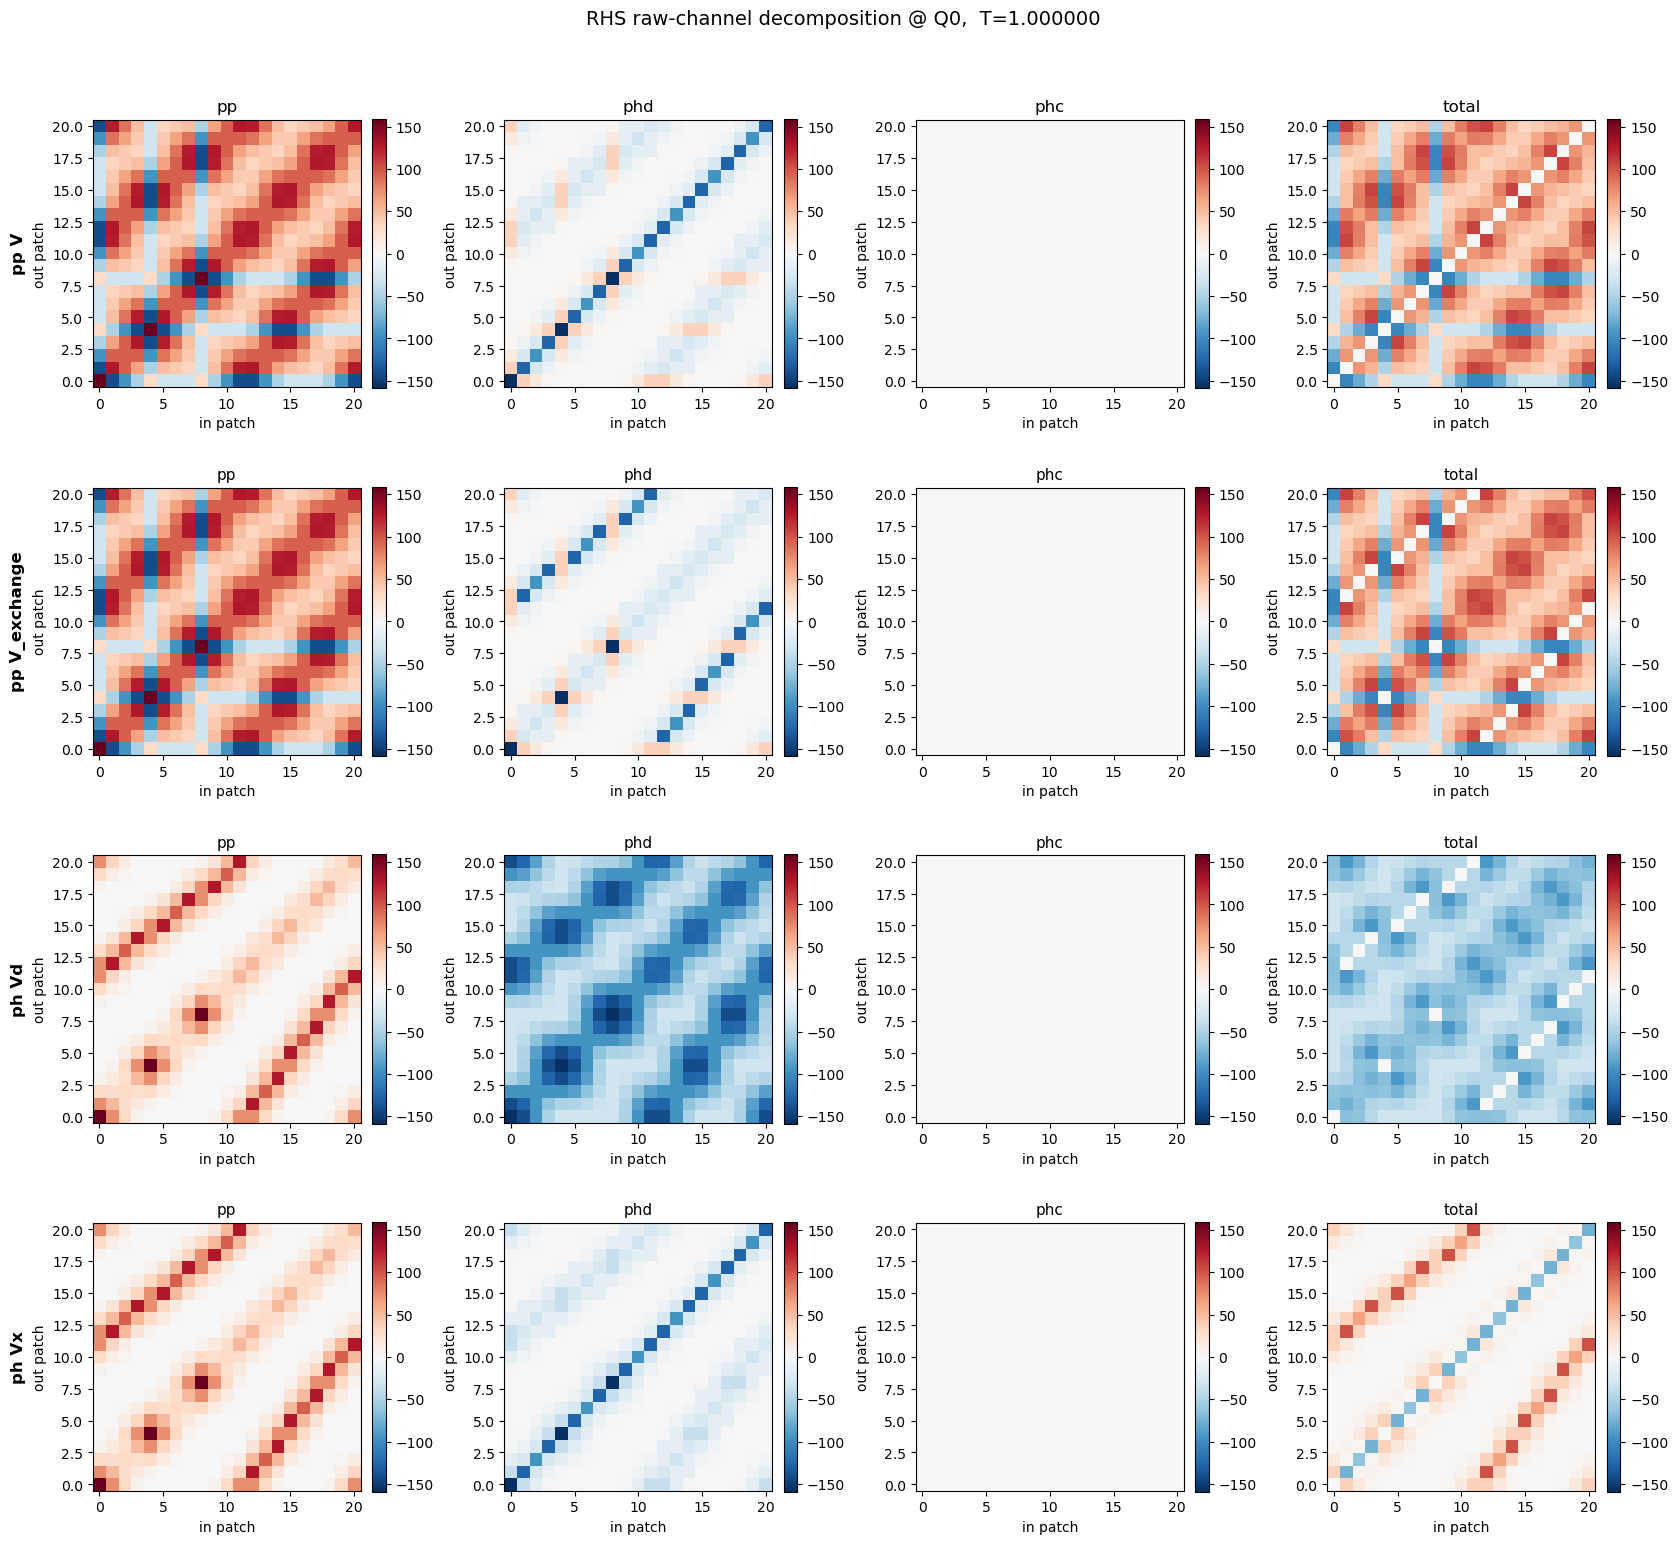

[early step 1]  T = 0.9949494949
     pp tensor max |.| = 1.835549e+02
    phd tensor max |.| = 1.457291e+02
    phc tensor max |.| = 3.517800e+01
  total tensor max |.| = 1.437217e+02


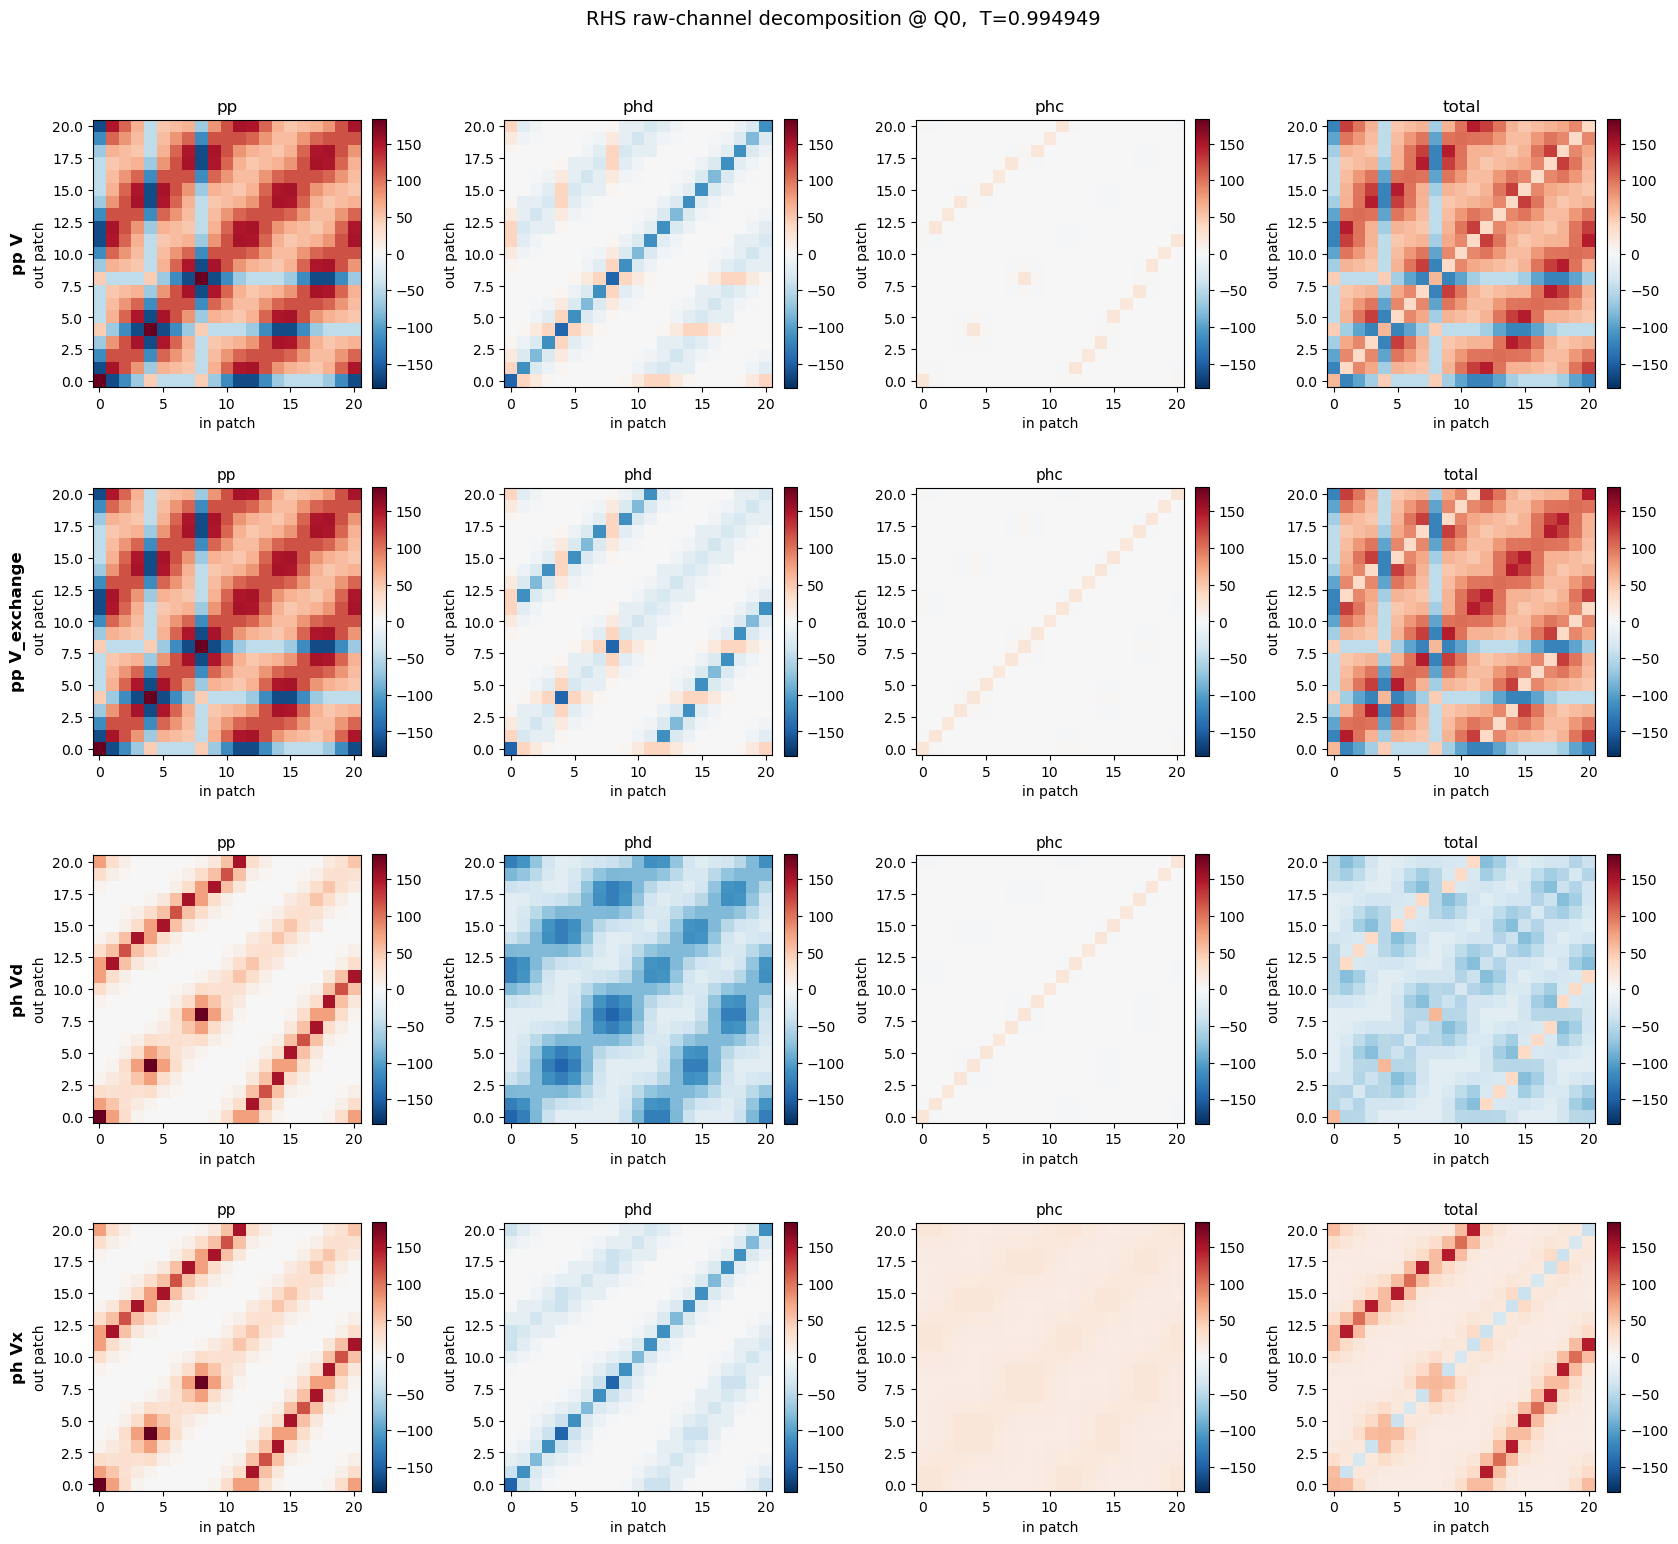

[early step 2]  T = 0.9898989899
     pp tensor max |.| = 2.189235e+02
    phd tensor max |.| = 1.388055e+02
    phc tensor max |.| = 4.879802e+01
  total tensor max |.| = 1.989680e+02


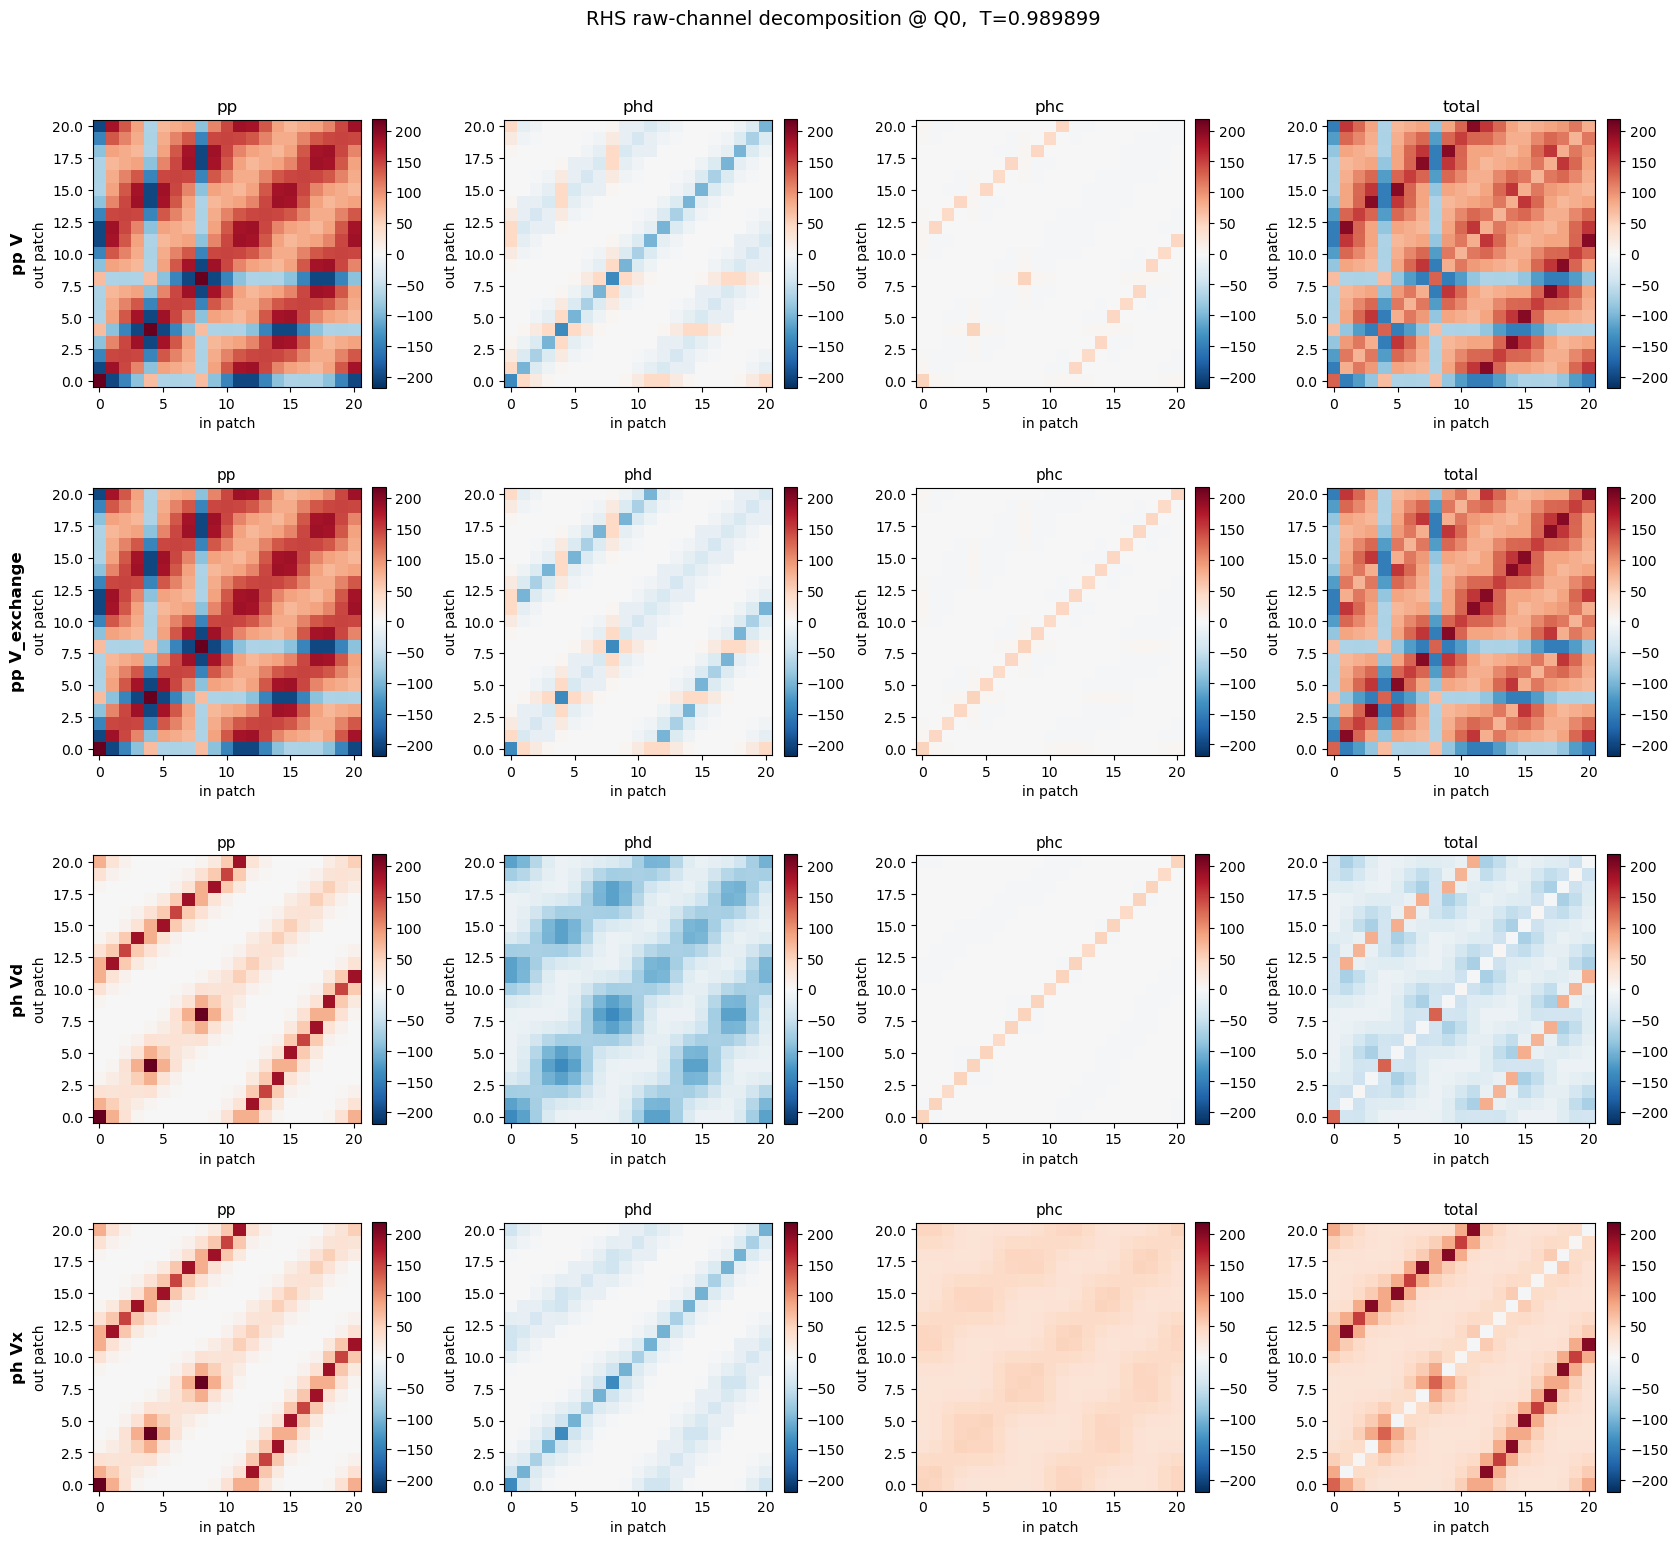


[inspect_early_flow_rhs_raw_channels] 已恢复 solver 原始状态。


In [69]:
# ============================================================
# 6. 你直接在这里指定要看的 Q
#    推荐先看 diagnosis_Qs，或者先只看 Q0 / QM1
# ============================================================
# 用你 notebook 里的 diagnosis_Qs，如果有的话
try:
    Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]
except Exception:
    Qs_to_check = [
        np.array([0.0, 0.0]),
    ]
print("Qs to check:", Qs_to_check)
# 你也可以手动覆盖，比如：
# Qs_to_check = [Q0, QM1, QM2, QM3]
# Q_labels = ["Q0", "QM1", "QM2", "QM3"]

Q_labels = [f"Q{i}" for i in range(len(Qs_to_check))]

# ============================================================
# 7. 运行
# ============================================================
inspect_early_flow_rhs_raw_channels(
    solver,                # 你当前 notebook 里的 solver 对象
    Qs_to_check,
    Q_labels=Q_labels,
    n_early_steps=3,       # 先看前 3 步
    use_real_part=True,    # True: 看实部；False: 看绝对值
)

# Debug

# Helper

In [2]:
from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray

def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )

def make_snapshot_accessor(snapshot):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])
    return accessor

def make_builder_from_snapshot(snapshot, solver):
    return SZ0ChannelBuilder(
        make_snapshot_accessor(snapshot),
        solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
    )

def kernel_bundle_at_Q(snapshot, solver, Q):
    """
    Return the 8 objects you want to visualize:
      pp: V, V_exchange, V_singlet, V_triplet
      ph: Vd, Vx, Vcharge, Vspin
    """
    builder = make_builder_from_snapshot(snapshot, solver)
    Q = np.array(Q, dtype=float)

    # pp
    V_pp_raw, _, _ = builder._pp_raw_v(Q)
    V_pp_ex = builder._pp_out_exchange_v(Q)
    K_pp_s = builder.pp_singlet(Q).matrix
    K_pp_t = builder.pp_triplet(Q).matrix

    # ph
    Vd = builder.ph_direct(Q).matrix
    Vx = builder.ph_exchange(Q).matrix
    K_ph_c = builder.ph_charge(Q).matrix
    K_ph_s = builder.ph_spin(Q).matrix

    return {
        "pp_V": V_pp_raw,
        "pp_V_exchange": V_pp_ex,
        "pp_singlet": K_pp_s,
        "pp_triplet": K_pp_t,
        "ph_Vd": Vd,
        "ph_Vx": Vx,
        "ph_charge": K_ph_c,
        "ph_spin": K_ph_s,
    }

def leading_eval(M):
    vals = np.linalg.eigvals(M)
    i = np.argmax(np.abs(vals))
    return vals[i]

def summarize_bundle(bundle):
    rows = []
    for name, M in bundle.items():
        lam = leading_eval(M)
        rows.append({
            "kernel": name,
            "max_abs_entry": float(np.max(np.abs(M))),
            "lead_eval_abs": float(np.abs(lam)),
            "lead_eval_real": float(np.real(lam)),
            "lead_eval_imag": float(np.imag(lam)),
        })
    import pandas as pd
    return pd.DataFrame(rows).sort_values("lead_eval_abs", ascending=False)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

# ------------------------------------------------------------
# reciprocal helpers
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can

# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]

def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]

def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # t = 0, 1/p, ..., (p-1)/p ; exclude t=1 to avoid explicit duplication
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)

def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)

# ------------------------------------------------------------
# duplicated-M removal (patch reps only)
# ------------------------------------------------------------
def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    """
    Return indices to KEEP among the standard exact-M loop points.

    Only the 6 anchor points are checked for modulo-G duplication:
        0, p, 2p, 3p, 4p, 5p
    where p = points_per_edge.

    All non-anchor points are always kept.
    """
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k = M6[local_anchor_idx]
        k_can = _canonicalize_k_mod_G(model, k)

        duplicated = False
        for q_can in seen_classes:
            if np.linalg.norm(k_can - q_can) < tol:
                duplicated = True
                break

        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)

    return np.flatnonzero(keep)

# ------------------------------------------------------------
# gauge fixing
# ------------------------------------------------------------
def _normalize_eigvec(u):
    u = np.asarray(u, dtype=complex)
    nrm = np.linalg.norm(u)
    if nrm == 0:
        raise ValueError("Encountered zero-norm eigenvector.")
    return u / nrm

def _anchor_phase(u, method="max_component"):
    u = _normalize_eigvec(u)
    if method == "max_component":
        idx = int(np.argmax(np.abs(u)))
        if np.abs(u[idx]) > 0:
            u = u * np.exp(-1j * np.angle(u[idx]))
    elif method == "first_component":
        if np.abs(u[0]) > 0:
            u = u * np.exp(-1j * np.angle(u[0]))
    else:
        raise ValueError("method must be 'max_component' or 'first_component'")
    return u

def smooth_patch_eigvecs(eigvecs, *, close_loop=True, anchor_method="max_component"):
    """
    Parallel-transport gauge fixing along the kept patch loop.

    1. Anchor first vector phase.
    2. For each next patch, rotate so <u_i | u_{i+1}> is real positive.
    3. Optionally distribute the final loop mismatch around the loop.

    Returns
    -------
    U_fixed : ndarray, shape (Npatch, Norb)
    loop_phase : float
        phase mismatch of the final overlap before loop closure correction.
    """
    U = np.asarray(eigvecs, dtype=complex).copy()
    if U.ndim != 2:
        raise ValueError("eigvecs must have shape (Npatch, Norb).")

    N = U.shape[0]
    if N == 0:
        return U, 0.0

    U[0] = _anchor_phase(U[0], method=anchor_method)

    for p in range(1, N):
        U[p] = _normalize_eigvec(U[p])
        ov = np.vdot(U[p - 1], U[p])
        if np.abs(ov) > 1e-14:
            U[p] *= np.exp(-1j * np.angle(ov))
        else:
            U[p] = _anchor_phase(U[p], method=anchor_method)

    loop_phase = 0.0
    if N > 1:
        ov_last = np.vdot(U[-1], U[0])
        if np.abs(ov_last) > 1e-14:
            loop_phase = float(np.angle(ov_last))

    if close_loop and N > 1 and np.abs(loop_phase) > 1e-14:
        # distribute mismatch smoothly along the loop
        for p in range(N):
            U[p] *= np.exp(1j * (p / N) * loop_phase)

        # re-anchor first patch and re-parallel-transport to keep neighboring overlaps smooth
        U[0] = _anchor_phase(U[0], method=anchor_method)
        for p in range(1, N):
            ov = np.vdot(U[p - 1], U[p])
            if np.abs(ov) > 1e-14:
                U[p] *= np.exp(-1j * np.angle(ov))

    for p in range(N):
        U[p] = _normalize_eigvec(U[p])

    return U, loop_phase

# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    *,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
    gauge_fix=True,
    close_loop_gauge=True,
    gauge_anchor="max_component",
):
    # 1) full standard loop
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    # 2) patch reps may be reduced; contour stays full
    if remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
        K_patch = K_full[keep_idx]
    else:
        keep_idx = np.arange(len(K_full))
        K_patch = K_full

    bz_vertices = _hex_bz_vertices_for_plot(model)

    # 3) raw eigvecs / energies / velocities on kept patch reps
    raw_eigvecs = []
    energies = []
    velocities = []

    for k in K_patch:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)

    raw_eigvecs = np.asarray(raw_eigvecs, dtype=complex)

    # 4) explicit gauge fixing on kept patch loop
    if gauge_fix:
        fixed_eigvecs, loop_phase = smooth_patch_eigvecs(
            raw_eigvecs,
            close_loop=close_loop_gauge,
            anchor_method=gauge_anchor,
        )
        gauge_method = "manual_exact_M_hex_parallel_transport"
    else:
        fixed_eigvecs = np.asarray([_normalize_eigvec(u) for u in raw_eigvecs], dtype=complex)
        loop_phase = 0.0
        gauge_method = "manual_exact_M_hex_raw"

    # 5) PatchPoint
    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K_patch, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix_dup = "_dropDupM" if remove_duplicate_M_modG else ""
    suffix_g = "_gaugeFixed" if gauge_fix else "_rawGauge"

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # keep original full contour
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )
def plot_bundle_2d(bundle, title_prefix="", *, use_abs=False):
    names = [
        "pp_V", "pp_V_exchange", "pp_singlet", "pp_triplet",
        "ph_Vd", "ph_Vx", "ph_charge", "ph_spin",
    ]
    titles = [
        "pp: V", "pp: V_exchange", "pp: V_singlet", "pp: V_triplet",
        "ph: Vd", "ph: Vx", "ph: Vcharge", "ph: Vspin",
    ]

    mats = [bundle[n] for n in names]

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.ravel()

    for ax, M, ttl in zip(axes, mats, titles):
        X = np.abs(M) if use_abs else np.real(M)
        im = ax.imshow(X, origin="lower", aspect="auto")
        ax.set_title(ttl)
        ax.set_xlabel("in patch")
        ax.set_ylabel("out patch")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(title_prefix + (" | abs" if use_abs else " | real"), fontsize=14)
    plt.tight_layout()
    plt.show()
import copy
import numpy as np
import matplotlib.pyplot as plt

from frg_kernel import (
    compute_pp_vertex_contribution_sz0,
    compute_phd_vertex_contribution_sz0,
    compute_phc_vertex_contribution_sz0,
)
from channels import SZ0ChannelBuilder


# ============================================================
# 1. 从任意 tensor 构造一个和 solver 当前语义一致的 vertex accessor
# ============================================================
def make_tensor_accessor_from_solver(solver, tensor3):
    p4_idx = solver.state.vertex.p4_index
    tensor3 = np.asarray(tensor3, dtype=complex)

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_idx[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        return complex(tensor3[p1, p2, p3])

    return accessor


# ============================================================
# 2. 把当前 RHS 拆成 pp / phd / phc 三个 3-index tensor
#    这里完全复刻 solver.compute_vertex_rhs(...) 的逻辑
# ============================================================
def compute_rhs_split_tensors(solver, T=None):
    if T is None:
        T = float(solver.state.T)

    pp_internal_by_iq, ph_internal_by_iq, phc_internal_by_iq = solver._refresh_cache_weights(T)

    Np = solver.Npatch
    pp_tensor  = np.zeros_like(solver.state.vertex.data, dtype=complex)
    phd_tensor = np.zeros_like(solver.state.vertex.data, dtype=complex)
    phc_tensor = np.zeros_like(solver.state.vertex.data, dtype=complex)

    p4_idx = solver.state.vertex.p4_index

    qpp  = solver._pp_q_index[("up", "dn")]
    qphd = solver._phd_q_index_plus[("up", "dn")]
    qphc = solver._phc_q_index_plus[("dn", "dn")]   # 保持和 flow 当前实现完全一致

    v_accessor = solver.current_vertex_accessor()

    for p1 in range(Np):
        for p2 in range(Np):
            pp_cache = pp_internal_by_iq[int(qpp[p1, p2])]
            for p3 in range(Np):
                p4 = int(p4_idx[p1, p2, p3])
                if p4 < 0:
                    continue

                phd_cache = ph_internal_by_iq[int(qphd[p1, p3])]
                phc_cache = phc_internal_by_iq[int(qphc[p2, p3])]

                pp_tensor[p1, p2, p3] = compute_pp_vertex_contribution_sz0(
                    v_accessor, p1=p1, p2=p2, p3=p3, p4=p4, internal_cache=pp_cache
                )
                phd_tensor[p1, p2, p3] = compute_phd_vertex_contribution_sz0(
                    v_accessor, p1=p1, p2=p2, p3=p3, p4=p4, internal_cache=phd_cache
                )
                phc_tensor[p1, p2, p3] = compute_phc_vertex_contribution_sz0(
                    v_accessor, p1=p1, p2=p2, p3=p3, p4=p4, internal_cache=phc_cache
                )

    total_tensor = pp_tensor + phd_tensor + phc_tensor
    return {
        "pp": pp_tensor,
        "phd": phd_tensor,
        "phc": phc_tensor,
        "total": total_tensor,
    }


# ============================================================
# 3. 给一个 tensor 和一个 Q，把四个 raw channel matrix 都构造出来
# ============================================================
def build_raw_channel_matrices_from_tensor(solver, tensor3, Q):
    accessor = make_tensor_accessor_from_solver(solver, tensor3)

    builder = SZ0ChannelBuilder(
        accessor,
        solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
    )

    Q = np.asarray(Q, dtype=float)

    # pp raw V
    ppV, _, _ = builder._pp_raw_v(Q)

    # pp raw V_exchange
    ppVx = builder._pp_out_exchange_v(Q)

    # ph raw Vd
    phVd = builder.ph_direct(Q).matrix

    # ph raw Vx
    phVx = builder.ph_exchange(Q).matrix

    return {
        "pp V": ppV,
        "pp V_exchange": ppVx,
        "ph Vd": phVd,
        "ph Vx": phVx,
    }


# ============================================================
# 4. 画图：4 行 raw channel × 4 列 topology
# ============================================================
def plot_rhs_raw_channel_panels(
    mats_by_topology,
    *,
    title="",
    real_part=True,
    cmap="RdBu_r",
):
    raw_names = ["pp V", "pp V_exchange", "ph Vd", "ph Vx"]
    topo_names = ["pp", "phd", "phc", "total"]

    # 全局色标，方便同一张图里横向比较
    all_vals = []
    for topo in topo_names:
        for raw in raw_names:
            M = mats_by_topology[topo][raw]
            X = np.real(M) if real_part else np.abs(M)
            all_vals.append(np.max(np.abs(X)))
    vmax = max(all_vals) if len(all_vals) > 0 else 1.0
    vmax = max(vmax, 1e-12)

    fig, axes = plt.subplots(len(raw_names), len(topo_names), figsize=(4.2 * len(topo_names), 3.8 * len(raw_names)))
    if len(raw_names) == 1 and len(topo_names) == 1:
        axes = np.array([[axes]])
    elif len(raw_names) == 1:
        axes = axes[None, :]
    elif len(topo_names) == 1:
        axes = axes[:, None]

    for i, raw in enumerate(raw_names):
        for j, topo in enumerate(topo_names):
            ax = axes[i, j]
            M = mats_by_topology[topo][raw]
            X = np.real(M) if real_part else np.abs(M)

            if real_part:
                im = ax.imshow(X, origin="lower", cmap=cmap, vmin=-vmax, vmax=vmax)
            else:
                im = ax.imshow(X, origin="lower", cmap="viridis", vmin=0, vmax=vmax)

            ax.set_title(f"{topo}", fontsize=11)
            ax.set_xlabel("in patch")
            ax.set_ylabel("out patch")
            if i == 0:
                ax.set_title(f"{topo}", fontsize=12)
            if j == 0:
                ax.text(
                    -0.28, 0.5, raw,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold"
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()


# ============================================================
# 5. 主函数：分析 early flow 前几步，每一步都看 RHS 的 raw-channel 分解
#    这个函数会在最后恢复 solver，不会永久改坏你当前对象
# ============================================================
def inspect_early_flow_rhs_raw_channels(
    solver,
    Qs,
    *,
    Q_labels=None,
    n_early_steps=3,
    use_real_part=True,
):
    """
    参数
    ----
    solver : 当前 FRGFlowSolverSZ0 对象
    Qs     : 要检查的一组 Q，list of 2d vectors
    Q_labels : 可选，和 Qs 等长的标签
    n_early_steps : 看前几步（在每一步“更新前”的 T 上看 RHS）
    """

    # ---------- 保存现场，最后恢复 ----------
    T0 = float(solver.state.T)
    data0 = solver.state.vertex.data.copy()
    history0 = copy.deepcopy(solver.history)
    inst0 = copy.deepcopy(solver.instability_record)

    # 温度路径
    temps = np.asarray(solver.temperature_path, dtype=float)

    # 如果当前 T 不在 path 的第一个位置，自动从最接近的地方往后走
    start_idx = int(np.argmin(np.abs(temps - solver.state.T)))

    if Q_labels is None:
        Q_labels = [f"Q[{i}]" for i in range(len(Qs))]

    try:
        for local_step in range(n_early_steps):
            idx = start_idx + local_step
            if idx >= len(temps):
                print(f"已经到 temperature_path 末尾，停止在 local_step={local_step}")
                break

            T_cur = float(solver.state.T)

            print("=" * 100)
            print(f"[early step {local_step}]  T = {T_cur:.10f}")

            # 1) 先拆 RHS 三个 topology
            rhs_split = compute_rhs_split_tensors(solver, T=T_cur)

            # 打印一下这三个 topology 的 tensor max，先看量级
            for topo_name in ["pp", "phd", "phc", "total"]:
                mx = np.max(np.abs(rhs_split[topo_name]))
                print(f"  {topo_name:>5s} tensor max |.| = {mx:.6e}")

            # 2) 对每个 Q，把四个 raw channel matrix 画出来
            for Q, qlab in zip(Qs, Q_labels):
                mats_by_topology = {}
                for topo_name in ["pp", "phd", "phc", "total"]:
                    mats_by_topology[topo_name] = build_raw_channel_matrices_from_tensor(
                        solver,
                        rhs_split[topo_name],
                        Q=np.asarray(Q, dtype=float),
                    )

                plot_rhs_raw_channel_panels(
                    mats_by_topology,
                    title=f"RHS raw-channel decomposition @ {qlab},  T={T_cur:.6f}",
                    real_part=use_real_part,
                )

            # 3) 推进一步，进入下一 early step
            if idx + 1 < len(temps):
                T_old = float(temps[idx])
                T_new = float(temps[idx + 1])
                _ = solver.step(T_old, T_new - T_old)
            else:
                print("下一步没有更多温度点了。")
                break

    finally:
        # ---------- 恢复现场 ----------
        solver.state.vertex.data[:] = data0
        solver.state.T = float(T0)
        solver.history = history0
        solver.instability_record = inst0
        print("\n[inspect_early_flow_rhs_raw_channels] 已恢复 solver 原始状态。")



In [3]:
import sys
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt

# Make sure uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from interaction import BareExtendedHubbard
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from channels import SZ0ChannelBuilder

# patching utilities for your manual exact-M patch cell
from patching import PatchPoint, PatchSet, plot_patchset